In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from quantem.tomography.tomography_lite import TomographyLiteConv, TomographyLiteINR
import numpy as np
from quantem.core.visualization import show_2d

from quantem.core.utils.tomography_utils import fourier_binning

device = "cuda:1" # Set device

/home/cedlim/quantem/quantem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Run Local Tensorboard

In [3]:
%load_ext tensorboard
%tensorboard --logdir ../../../outputs/tomography/tutorial_01_notebooks

In [4]:
from tensorboard import notebook
notebook.list() # View open TensorBoard instances
notebook.display(port=6006, height=1000)

Known TensorBoard instances:
  - port 6006: logdir logs (started 26 days, 18:58:16 ago; pid 1678239)
  - port 6006: logdir tutorial_02 (started 4 days, 20:35:26 ago; pid 3060009)
  - port 6006: logdir ../../../outputs/tomography/tutorial_01_notebooks (started 0:00:03 ago; pid 4129877)
  - port 6006: logdir logs (started 27 days, 2:46:14 ago; pid 1592877)
  - port 6006: logdir logs (started 25 days, 9:04:27 ago; pid 2141659)
  - port 6006: logdir tomography/ (started 28 days, 1:45:20 ago; pid 1158588)
  - port 6006: logdir logs/ (started 26 days, 6:45:54 ago; pid 1771946)
  - port 6006: logdir logs (started 26 days, 0:54:26 ago; pid 1928360)
Selecting TensorBoard with logdir ../../../outputs/tomography/tutorial_01_notebooks (started 0:00:03 ago; port 6006, pid 4129877).


In [5]:
# Load Phantom Dataset
tilt_series = np.load('../../../data/tilt_series_no_errors.npy')
tilt_angles = np.load('../../../data/tilt_angles.npy')

# Fourier crop
tilt_series = np.array([fourier_binning(img, (100, 100)) for img in tilt_series]) # Cropped down to 100x100 for speed


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

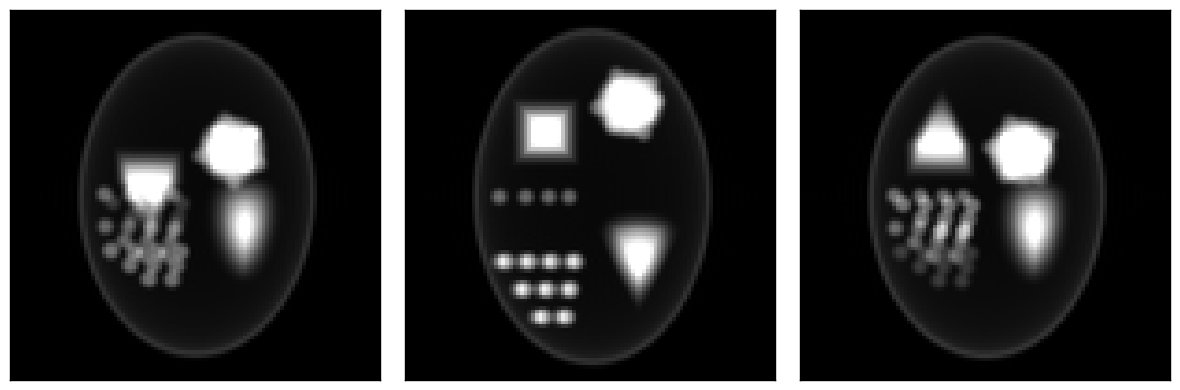

In [6]:
show_2d(
    [tilt_series[0], tilt_series[30], tilt_series[60]],
)

# Conventional Tomography Reconstructions
*Cedric Lim, 2/1/26*

In [7]:
tomography = TomographyLiteConv.from_dataset(
    tilt_series = tilt_series,
    tilt_angles = tilt_angles,
    device = device,
)

In [8]:
tomography.reconstruct(
    num_iter = 10,
    inline_alignment = True,
    smoothing_sigma = 0.5,
)

sirt Reconstruction:   0%|          | 0/10 [00:00<?, ?it/s]

proj_forward.shape torch.Size([100, 61, 100])
self.dset.tilt_stack.shape torch.Size([61, 100, 100])


sirt Reconstruction | Loss: 0.0230: 100%|██████████| 10/10 [00:00<00:00, 11.24it/s]


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

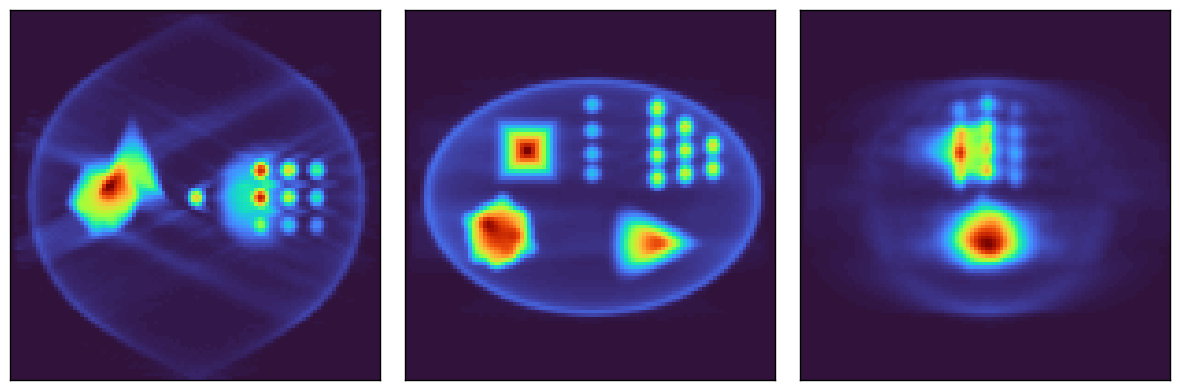

In [9]:
obj = tomography.obj_model.obj.detach().cpu().numpy()
show_2d(
    [obj.sum(axis = 0), obj.sum(axis = 1), obj.sum(axis = 2)],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)

# INR-Based Tomography Reconstruction

In [10]:
tomography_inr = TomographyLiteINR.from_dataset(
    tilt_series = tilt_series,
    tilt_angles = tilt_angles,
    device = device,
    log_dir = '../../../outputs/tomography/tutorial_01_notebooks/tomo_inr_lite',
    log_images_every = 2,
)


Model built, compiled successfully
Setting up DDP for obj_model


In [ ]:
obj_constraints = {
    "positivity": True,
    "tv_vol": 1e-5,
    "sparsity": 1e-6,
}

dset_constraints = {
    "tv_zs": 1e-6,
    "tv_shifts": 1e-6,
}   

tomography_inr.reconstruct(
    num_iter = 20,
    # reset = True,
    obj_lr = 1e-4,
    pose_lr = 1e-2,
    batch_size = 1024,
    num_workers = 32,
    learn_pose = True,
    scheduler_type = "cosine_annealing",
    obj_constraints = obj_constraints,
    dset_constraints = dset_constraints,
)

Dataloader setup complete:
  Total train samples: 610000
  Local batch size: 1024
  Global batch size: 1024
  Train batches per GPU per epoch: 595


Reconstruction | Loss: 0.0005, Consistency Loss: 0.0002, Soft Constraint Loss: 0.0003 | Logger Updated:  40%|████      | 8/20 [01:19<01:57,  9.78s/it]

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

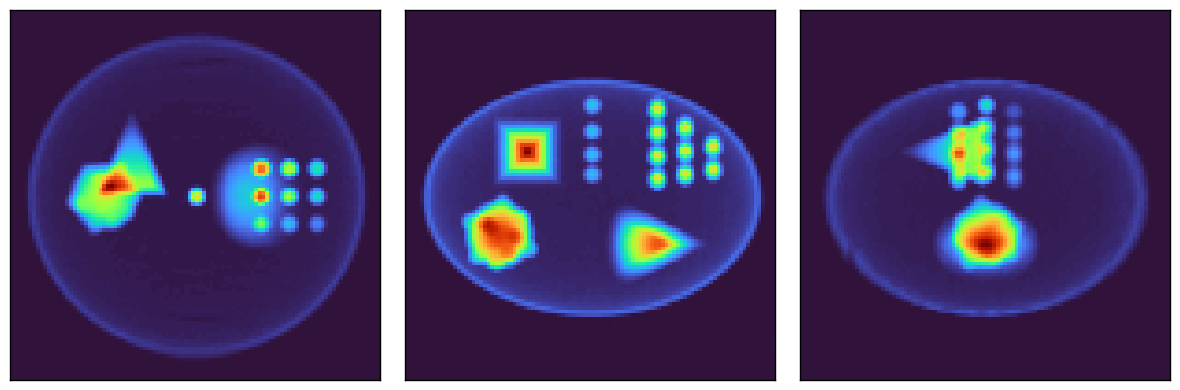

In [10]:
tomography_inr.obj_model.create_volume()
obj = tomography_inr.obj_model.obj.detach().cpu().numpy()[0].transpose(0, 2, 1)
show_2d(
    [obj.sum(axis = 0), obj.sum(axis = 1), obj.sum(axis = 2)],
    cmap = 'turbo',
    vmin = 0,
    vmax = None,
)